<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Machine-Learning-repo/blob/main/Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np

import scipy.stats as stats     # used for statistics analysis and probability

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score   # cross value evaluates models performance more reliably

from sklearn.linear_model import LogisticRegression
from sklearn.tree  import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [19]:
df=pd.read_csv("/content/train.csv", usecols=["Age","Fare","Survived"])

In [20]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

/tmp/ipython-input-2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [21]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [22]:
X= df.iloc[:,1:3]
y=df.iloc[:,0]

In [23]:
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

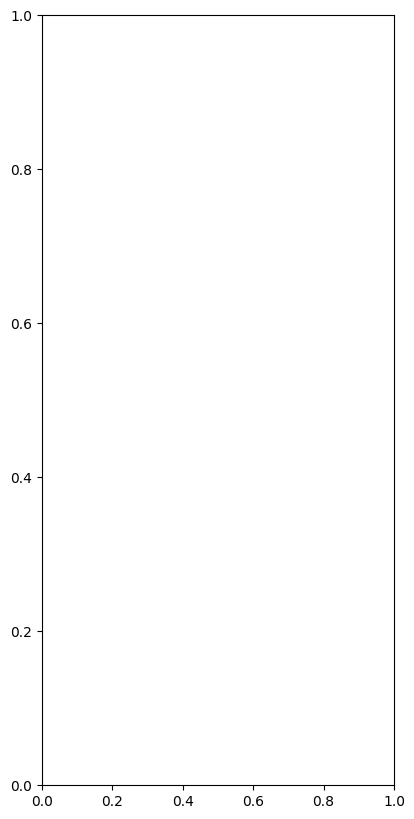

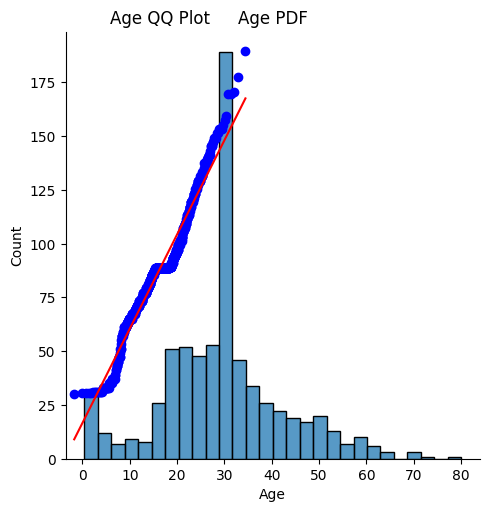

In [24]:
plt.figure(figsize=(10,10))
plt.subplot(121)
sns.displot(X_train["Age"])
plt.title("Age PDF")

plt.subplot(121)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")
plt.axis("off")
plt.show()

Making class of objects


In [25]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()


In [26]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy  DT",accuracy_score(y_test,y_pred))

Accuracy LR 0.6480446927374302
Accuracy  DT 0.6480446927374302


In [27]:
trf=FunctionTransformer(func=np.log1p)


In [28]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.fit_transform(x_test)

In [29]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)    # objext creaTION
clf2.fit(X_train_transformed,y_train)

y_pred=clf.predict(X_test_transformed)
y_pred1=clf.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DI",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DI 0.6815642458100558


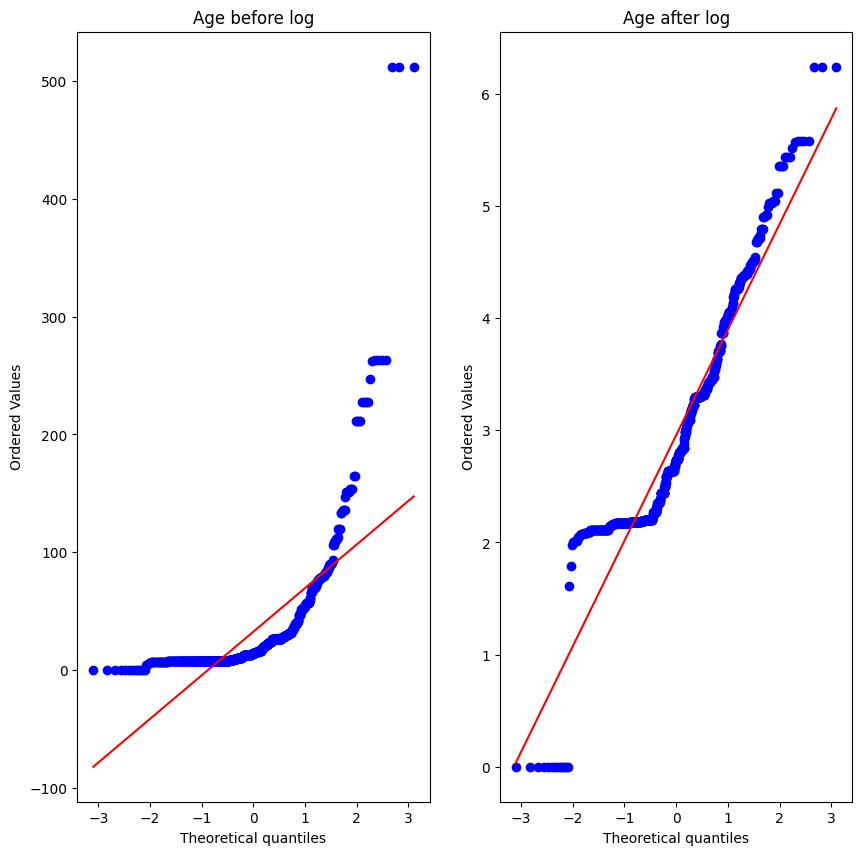

In [30]:
plt.figure(figsize=(10,10))

plt.subplot(121)
stats.probplot(X_train["Fare"], dist="norm",plot=plt)
plt.title("Age before log")

plt.subplot(122)
stats.probplot(X_train_transformed["Fare"],dist="norm",plot=plt)
plt.title("Age after log")
plt.show()

POwer transformer

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as ststs  # calculating the statistics part


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [33]:
df= pd.read_csv("/content/concrete_data.csv")

In [34]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [35]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [36]:
x = df.drop(columns=["Strength"])
y=df.iloc[:,-1]

In [37]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
# Appplying box-cox transformer

pt=PowerTransformer(method="box-cox")

X_train_transformed= pt.fit_transform(X_train+0.0000001)
X_test_transformed=pt.fit_transform(X_test+0.0000001)

pd.DataFrame({"cols":X_train.columns,"box_cox_lambdas":pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.023556
2,Fly Ash,-0.005774
3,Water,0.959062
4,Superplasticizer,0.091027
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [39]:
# Applying linear regrtession
lr= LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred=lr.predict(X_test_transformed)

r2_score(y_test,y_pred)

0.8050550263406665

In [40]:
# Applying Yeo-Johnson

pt1=PowerTransformer()

X_train_transformed1=pt1.fit_transform(X_train)
X_test_transformed1=pt1.fit_transform(X_test)

lr=LinearRegression()
lr.fit(X_train_transformed1,y_train)

y_pred3= lr.predict(X_test_transformed1)

print(r2_score(y_test,y_pred3))

0.8153845514592458


In [41]:
# Comparison betweeen box-cox and Yeo Johnson
pd.DataFrame({"cols": X_train.columns,"box-cox_lambdas":pt.lambdas_,"Yeo_Johnson_lambdas":pt1.lambdas_})

,cols,box-cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.215602,0.213025
1,Blast Furnace Slag,0.023556,0.020476
2,Fly Ash,-0.005774,-0.038218
3,Water,0.959062,0.958936
4,Superplasticizer,0.091027,0.304951
5,Coarse Aggregate,1.192492,1.192751
6,Fine Aggregate,1.973781,1.975085
7,Age,-0.014692,-0.062443
